# Cohort Retention and Predicting Who Comes Back

This follows on from notebook 1, where the main finding was that most Olist customers buy only once. The real question is not just whether they buy again, but whether we can spot the small share who do before they disappear.

This notebook looks at two follow-up questions:

1. **Cohort retention:** among customers whose first purchase fell in a given month, how many return in later months?
2. **Repeat-purchase prediction:** using only a customer's *first* purchase, can we predict who is likely to buy again?

**Methods:** cohort analysis · retention heatmap · class imbalance · time-based validation · logistic regression vs. gradient boosting · leakage-safe target encoding · point-in-time features · ROC-AUC, PR-AUC, lift and cumulative gains · bootstrap confidence intervals · odds-ratio interpretation

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from scipy.stats import rankdata

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import OUTPUT_DIR, FIGURES_DIR, RANDOM_STATE
from src.data import load_tables
from src.style import apply_style, SURFACE, INK, INK_2, MUTED, GRID, AXIS, BLUE, ORANGE, RED, SEGMENT_PALETTE
apply_style()

## 2. Load and prepare the data

We keep only delivered orders with a payment record and identify customers using `customer_unique_id` rather than `customer_id`.

One definition matters here: a second order on the same day as the first often reflects a single shopping session split across multiple orders, not a true repeat purchase. To avoid overcounting, we treat everything bought on a customer's first day as **one initial purchase**. A **genuine return** is any order placed on a later day.

In [2]:
tables = load_tables()
customers, orders, payments = tables["customers"], tables["orders"], tables["payments"]
reviews, items, products = tables["reviews"], tables["items"], tables["products"]
cat_names, sellers = tables["category_names"], tables["sellers"]

df = (orders[(orders.order_status == "delivered") & orders.order_id.isin(payments.order_id)]
      .merge(customers[["customer_id", "customer_unique_id", "customer_state", "customer_city", "customer_zip_code_prefix"]],
             on="customer_id"))
df["purchase_day"] = df.order_purchase_timestamp.dt.normalize()
df = df.join(df.groupby("customer_unique_id").purchase_day.min().rename("first_day"), on="customer_unique_id")

DATA_END = df.purchase_day.max()

# One row per customer: first purchase day, state, and the day of their first genuine return (if any)
cust = df.groupby("customer_unique_id").agg(first_day=("first_day", "first"), state=("customer_state", "first"),
                                            city=("customer_city", "first"), zip=("customer_zip_code_prefix", "first"))
first_return = df[df.purchase_day > df.first_day].groupby("customer_unique_id").purchase_day.min()
cust["return_day"] = first_return.reindex(cust.index)
cust["days_to_return"] = (cust.return_day - cust.first_day).dt.days

print(f"Customers:        {len(cust):,}")
print(f"Ever returned:    {cust.return_day.notna().sum():,} ({cust.return_day.notna().mean():.1%})")
print(f"Data ends:        {DATA_END:%d %b %Y}")

Customers:        93,357
Ever returned:    2,015 (2.2%)
Data ends:        29 Aug 2018


# Part A: Cohort retention

A **cohort** is a group of customers whose first purchase fell in the same month. For each cohort, we measure the share that places a genuine return order 1, 2, 3 months later, and so on.

A common mistake is to fill unobserved months with 0%. For example, the January 2018 cohort cannot yet have a full 12-month history because the data ends in August 2018, so those cells are left **blank** rather than treated as zero retention.

In [3]:
df["cohort"] = df.first_day.dt.to_period("M")
df["months_since_first"] = (df.purchase_day.dt.to_period("M") - df.cohort).apply(lambda p: p.n)

cohort_size = df.groupby("cohort").customer_unique_id.nunique()
returns = df[df.purchase_day > df.first_day]
active = returns.groupby(["cohort", "months_since_first"]).customer_unique_id.nunique().unstack(fill_value=0)
retention = active.div(cohort_size, axis=0) * 100

# Keeping the well-populated cohorts (Jan 2017 onwards) and months 1–12
MAX_MONTH = 12
retention = retention.reindex(index=pd.period_range("2017-01", DATA_END.to_period("M"), freq="M"),
                              columns=range(1, MAX_MONTH + 1)).fillna(0)
last_month = DATA_END.to_period("M")
for cohort in retention.index:
    for m in retention.columns:
        if cohort + m > last_month:
            retention.loc[cohort, m] = np.nan

print(f"Cohorts: {len(retention)} (Jan 2017 – {last_month.strftime('%b %Y')})")
print(f"Average month-1 retention: {retention[1].mean():.2f}%")
print(f"Highest single cell:       {np.nanmax(retention.values):.2f}%")

Cohorts: 20 (Jan 2017 – Aug 2018)
Average month-1 retention: 0.48%
Highest single cell:       0.72%


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


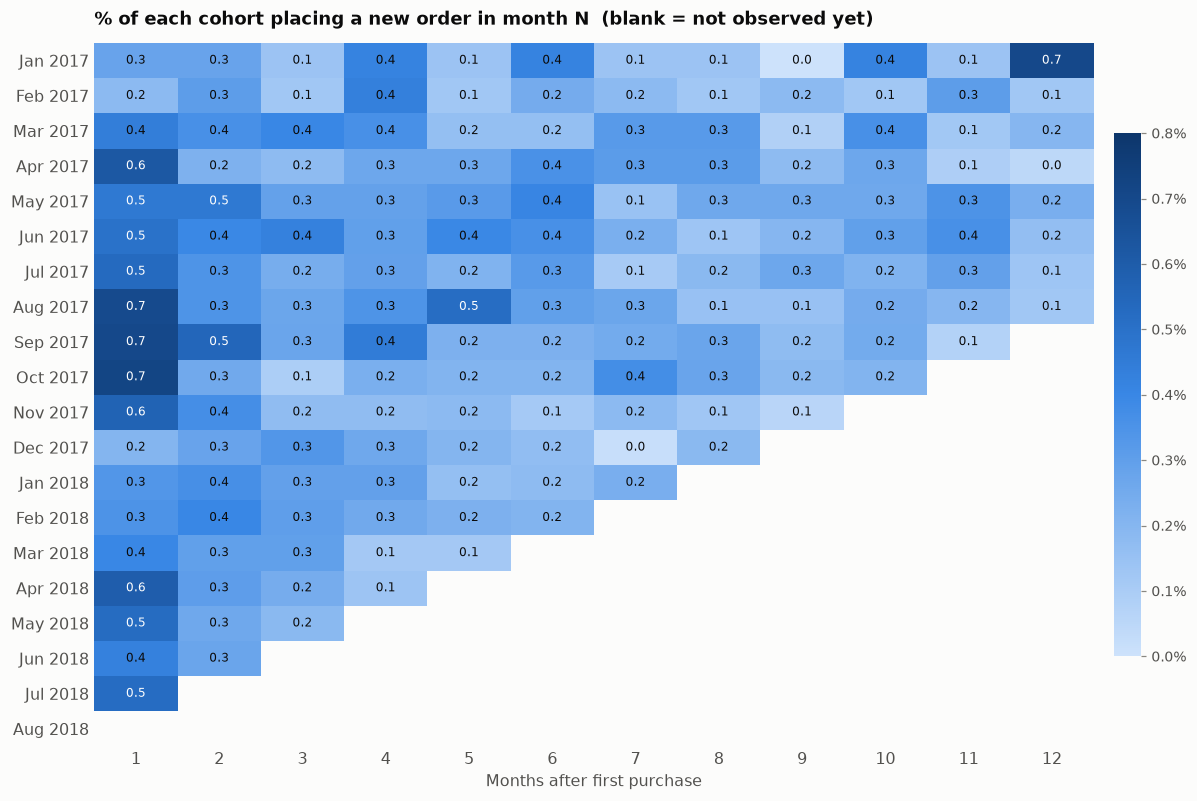

In [4]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue_seq", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
cmap.set_bad(SURFACE)

fig, ax = plt.subplots(figsize=(11, 7.4))
im = ax.imshow(retention.values, cmap=cmap, vmin=0, vmax=0.8, aspect="auto")
for i in range(retention.shape[0]):
    for j in range(retention.shape[1]):
        v = retention.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8,
                    color="white" if v >= 0.45 else INK)
ax.set_xticks(range(MAX_MONTH), range(1, MAX_MONTH + 1))
ax.set_yticks(range(len(retention)), [p.strftime("%b %Y") for p in retention.index])
ax.set_xlabel("Months after first purchase")
ax.set_title("% of each cohort placing a new order in month N  (blank = not observed yet)")
ax.tick_params(length=0); ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.outline.set_visible(False); cb.ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
cb.ax.tick_params(labelsize=9, color=MUTED)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "cohort_retention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the heatmap:** the pattern is the same as the chart above: every cell is below 1%. In a typical month, fewer than 1 in 100 customers from any cohort comes back, and the early 2017 and 2018 cohorts look almost identical. For comparison, subscription businesses often retain more than 50% after month 1. Here the "retention curve" is effectively flat on the floor from the very first month.

### How many customers eventually come back?

The heatmap shows returns month by month. The next question is how many customers return **at all** within a given period. To keep that comparison fair, we only include customers who have had at least a full year of history after their first purchase.

Customers with at least 365 days of history: 21,360


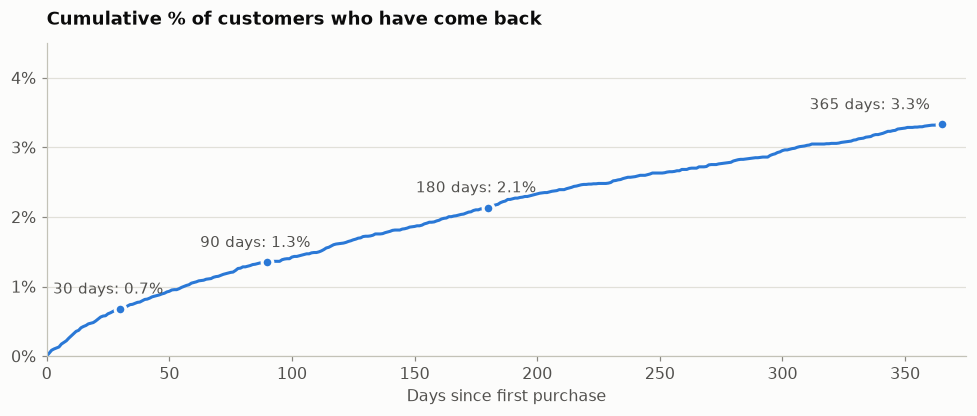

In [5]:
HORIZON = 365
mature = cust[cust.first_day <= DATA_END - pd.Timedelta(days=HORIZON)]
days = np.arange(0, HORIZON + 1)
cum_return = np.array([(mature.days_to_return <= d).mean() * 100 for d in days])

print(f"Customers with at least {HORIZON} days of history: {len(mature):,}")
fig, ax = plt.subplots(figsize=(9, 3.9))
ax.plot(days, cum_return, color=BLUE)
for d in [30, 90, 180, 365]:
    v = cum_return[d]
    ax.plot(d, v, "o", color=BLUE, markersize=7, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.annotate(f"{d} days: {v:.1f}%", (d, v), xytext=(-8, 10), textcoords="offset points",
                ha="right" if d == 365 else "center", color=INK_2, fontsize=9.5)
ax.set_xlim(0, HORIZON + 10); ax.set_ylim(0, 4.5); ax.set_yticks(range(0, 5))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlabel("Days since first purchase")
ax.set_title("Cumulative % of customers who have come back")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

The curve rises slowly and steadily, with no sharp early spike followed by a plateau. After a full year, only a few percent of customers have come back. That pattern fits a market where repeat purchases are driven by **new, unrelated needs** rather than by a relationship that was formed on the first order.

### Has retention improved as Olist grew?

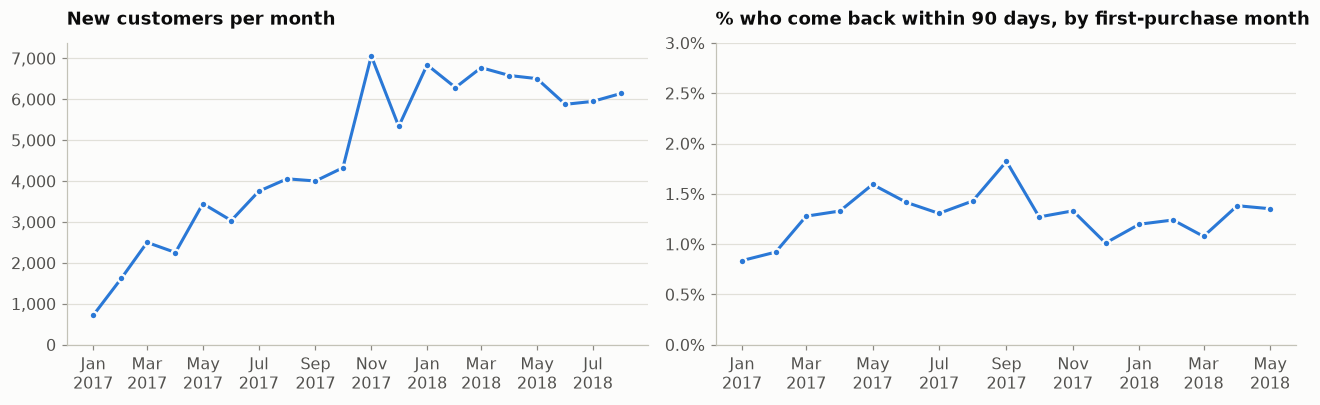

90-day return rate across cohorts: 0.8% – 1.8% (mean 1.3%)


In [7]:
WINDOW_90 = 90
eligible_90 = cust[(cust.first_day >= "2017-01-01") & (cust.first_day <= DATA_END - pd.Timedelta(days=WINDOW_90))]
ret_90 = (eligible_90.assign(r=eligible_90.days_to_return <= WINDOW_90)
          .groupby(eligible_90.first_day.dt.to_period("M")).r.mean() * 100)
new_customers = cust[cust.first_day >= "2017-01-01"].groupby(cust.first_day.dt.to_period("M")).size()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
x = ret_90.index.to_timestamp()
axes[0].plot(new_customers.index.to_timestamp(), new_customers.values, color=BLUE, marker="o", markersize=5,
             markeredgecolor=SURFACE, markeredgewidth=1.5)
axes[0].set_title("New customers per month"); axes[0].set_ylim(0)
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[1].plot(x, ret_90.values, color=BLUE, marker="o", markersize=5, markeredgecolor=SURFACE, markeredgewidth=1.5)
axes[1].set_title("% who come back within 90 days, by first-purchase month"); axes[1].set_ylim(0, 3)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
for ax in axes:
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b\n%Y")); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print(f"90-day return rate across cohorts: {ret_90.min():.1f}% – {ret_90.max():.1f}% (mean {ret_90.mean():.1f}%)")

**Takeaways from Part A**

- Growth was driven almost entirely by new customers; the 90-day return rate stayed roughly flat through 2017.
- Olist was good at **acquiring** customers, but not at **retaining** them.
- That makes a targeted retention model useful: a small, well-chosen group is far more valuable than broad outreach.

---

# Part B: Predicting who comes back

## 3. Framing the prediction problem

The setup matters more than the model.

| Decision | Choice | Why |
|---|---|---|
| **Who** | Every customer at their first purchase | Campaigns start right after the first order |
| **Target** | Return within **180 days** | Most returns happen early; a fixed window keeps comparisons fair |
| **Features** | Only first-purchase information | Anything later would be *leakage* |
| **Eligible customers** | Customers with at least 180 days of history | Recent buyers are not yet fully observed |
| **Train/test split** | Time-based split: before vs. after Jan 2018 | This matches real forecasting, not random validation |

**Timing note:** delivery and review data arrive a few days after purchase, so the model scores a customer only once that first order is complete enough to use.

In [8]:
WINDOW = 180
labelled = cust[cust.first_day <= DATA_END - pd.Timedelta(days=WINDOW)].copy()
labelled["came_back"] = (labelled.days_to_return <= WINDOW).astype(int)
print(f"Eligible customers: {len(labelled):,}")
print(f"Came back within {WINDOW} days: {labelled.came_back.sum():,} ({labelled.came_back.mean():.2%})")

Eligible customers: 56,035
Came back within 180 days: 1,109 (1.98%)


Only about **2%** of customers are positives, so this is a highly imbalanced classification problem.

- **Accuracy is not useful.** A model that predicts "won't come back" for everyone would be 98% accurate and still useless.
- We judge the model with **ROC-AUC** and **PR-AUC**: the first measures ranking quality, while the second is judged against the 2% base rate.
- For the business, the key metric is **lift**: how many more returners we reach in the top-scored 10% than we would by contacting 10% of customers at random.

## 4. Feature engineering: the first purchase

In [9]:
def build_features(customer_ids: pd.Index) -> pd.DataFrame:
    # Features describing each customer's first shopping day (all delivered orders placed that day)
    fo = df[(df.purchase_day == df.first_day) & df.customer_unique_id.isin(customer_ids)]
    feats = pd.DataFrame(index=customer_ids)

    # --- What they bought ---
    it = (items.merge(fo[["order_id", "customer_unique_id"]], on="order_id")
               .merge(products[["product_id", "product_category_name", "product_weight_g", "product_photos_qty"]],
                      on="product_id", how="left")
               .merge(cat_names, on="product_category_name", how="left"))
    it["category"] = it.product_category_name_english.fillna("unknown")
    g = it.groupby("customer_unique_id")
    priciest = it.sort_values("price", ascending=False).drop_duplicates("customer_unique_id").set_index("customer_unique_id")
    feats["n_orders_first_day"] = fo.groupby("customer_unique_id").order_id.nunique()
    feats["n_items"] = g.size()
    feats["n_sellers"] = g.seller_id.nunique()
    feats["n_categories"] = g.category.nunique()
    feats["max_item_price"] = g.price.max()
    feats["freight_share"] = g.freight_value.sum() / (g.price.sum() + g.freight_value.sum())
    feats["main_category"] = priciest.category
    feats["product_weight_g"] = priciest.product_weight_g
    feats["product_photos"] = priciest.product_photos_qty

    # --- How they paid ---
    p = payments.merge(fo[["order_id", "customer_unique_id"]], on="order_id")
    gp = p.groupby("customer_unique_id")
    feats["total_paid"] = gp.payment_value.sum()
    feats["installments"] = gp.payment_installments.max()
    feats["used_voucher"] = gp.payment_type.apply(lambda s: (s == "voucher").any()).astype(float)
    feats["payment_type"] = (p.sort_values("payment_value", ascending=False)
                              .drop_duplicates("customer_unique_id").set_index("customer_unique_id").payment_type)

    # --- How it was delivered ---
    fo = fo.assign(
        delivery_days=(fo.order_delivered_customer_date - fo.order_purchase_timestamp).dt.total_seconds() / 86400,
        promised_days=(fo.order_estimated_delivery_date - fo.order_purchase_timestamp).dt.total_seconds() / 86400,
        days_late=(fo.order_delivered_customer_date - fo.order_estimated_delivery_date).dt.total_seconds() / 86400)
    gf = fo.groupby("customer_unique_id")
    feats["delivery_days"] = gf.delivery_days.max()
    feats["promised_days"] = gf.promised_days.max()
    feats["days_late"] = gf.days_late.max()
    feats["was_late"] = (feats.days_late > 0).astype(float)

    # --- How they reviewed it ---
    r = reviews.merge(fo[["order_id", "customer_unique_id"]], on="order_id")
    gr = r.groupby("customer_unique_id")
    feats["review_score"] = gr.review_score.min()
    feats["wrote_comment"] = gr.review_comment_message.apply(lambda s: s.notna().any()).astype(float)

    # --- Who and when ---
    feats["state"] = cust.loc[customer_ids, "state"]
    feats["purchase_month"] = cust.loc[customer_ids, "first_day"].dt.strftime("%b")
    feats["purchase_weekday"] = cust.loc[customer_ids, "first_day"].dt.day_name()
    return feats

X_all = build_features(labelled.index)
y_all = labelled.came_back
CAT_COLS = ["main_category", "payment_type", "state", "purchase_month", "purchase_weekday"]
NUM_COLS = [c for c in X_all.columns if c not in CAT_COLS]
print(f"{X_all.shape[1]} features for {len(X_all):,} customers")
X_all.isna().sum()[lambda s: s > 0].rename("missing values").to_frame()

22 features for 56,035 customers


,missing values
product_weight_g,15
product_photos,1027
delivery_days,2
days_late,2


The few missing values — mainly products without photo counts, and a handful of orders with missing payment or delivery details — are imputed with medians learned from the training data only.

### A first look: who comes back more?

The chart compares the 5 lowest and 5 highest return-rate categories among those with at least 500 customers.

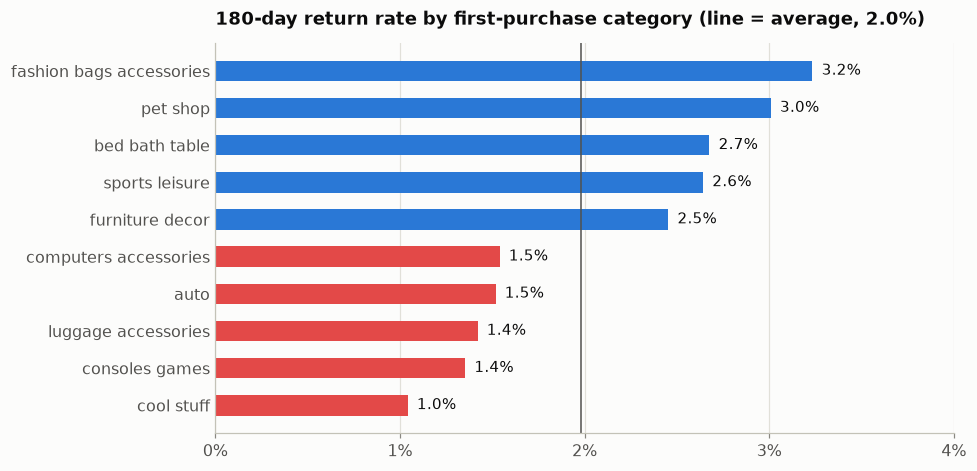

In [12]:
explore = X_all.assign(came_back=y_all)
by_cat = explore.groupby("main_category").came_back.agg(["mean", "size"])
by_cat = by_cat[by_cat["size"] >= 500].sort_values("mean")
show = pd.concat([by_cat.head(5), by_cat.tail(5)])
base = y_all.mean() * 100

fig, ax = plt.subplots(figsize=(9, 4.4))
colors = [RED if v * 100 < base else BLUE for v in show["mean"]]
ax.barh(show.index.str.replace("_", " "), show["mean"] * 100, height=0.55, color=colors)
for yv, v in enumerate(show["mean"] * 100):
    ax.text(v + 0.05, yv, f"{v:.1f}%", va="center", color=INK, fontsize=9.5)
ax.axvline(base, color=INK_2, linewidth=1)
ax.set_xlim(0, 4); ax.set_xticks(range(0, 5))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title(f"180-day return rate by first-purchase category (line = average, {base:.1f}%)")
ax.grid(axis="y", visible=False); ax.tick_params(axis="y", length=0)
plt.tight_layout(); plt.show()

In [13]:
def rate_table(col, labels=None):
    t = explore.groupby(col).came_back.agg(return_rate="mean", customers="size")
    t["return_rate"] = (t.return_rate * 100).round(2)
    return t

print("By number of separate orders on the first day:")
display(rate_table(explore.n_orders_first_day.clip(upper=3).map({1: "1", 2: "2", 3: "3+"}).rename("orders_on_first_day")))
print("By voucher use on the first purchase:")
display(rate_table(explore.used_voucher.map({0.0: "no voucher", 1.0: "used voucher"}).rename("voucher")))
print("By first-order review score:")
display(rate_table("review_score"))

By number of separate orders on the first day:


,return_rate,customers
orders_on_first_day,,
1,1.940,55363
2,4.780,649
3+,17.390,23


By voucher use on the first purchase:


,return_rate,customers
voucher,,
no voucher,1.960,53757
used voucher,2.500,2278


By first-order review score:


,return_rate,customers
review_score,,
1,1.740,5866
2,1.580,1838
3,1.930,4933
4,1.810,11201
5,2.110,32197


There are some early signals. Customers whose first purchase was in **fashion accessories, pet supplies or home goods** come back about twice as often as those who bought gadgets ("cool stuff"), games, luggage, auto parts or computer accessories. The few customers who placed **several orders on their first day** also return much more often, which suggests they are engaged, multi-need shoppers. **Voucher users** return slightly more, while **review score still barely matters**.

Each signal is weak on its own. The question is whether a model can combine them into a ranking that is useful in practice.

## 5. Train/test split by time

In [14]:
SPLIT_DATE = pd.Timestamp("2018-01-01")
is_train = labelled.first_day < SPLIT_DATE

# Collapse rare categories into "other", using TRAINING counts only (no peeking at the test set)
def collapse_rare(X, reference, col, keep_top):
    keep = reference[col].value_counts().index[:keep_top]
    return X[col].where(X[col].isin(keep), "other")

X = X_all.copy()
X["main_category"] = collapse_rare(X, X_all[is_train], "main_category", 25)
X["state"] = collapse_rare(X, X_all[is_train], "state", 12)

X_train, X_test = X[is_train], X[~is_train]
y_train, y_test = y_all[is_train], y_all[~is_train]

split_info = pd.DataFrame({
    "first purchase": [f"{labelled.first_day[is_train].min():%b %Y} – Dec 2017",
                       f"Jan 2018 – {labelled.first_day[~is_train].max():%d %b %Y}"],
    "customers": [len(X_train), len(X_test)],
    "came back": [y_train.sum(), y_test.sum()],
    "return rate": [f"{y_train.mean():.2%}", f"{y_test.mean():.2%}"],
}, index=["train", "test"])
split_info

,first purchase,customers,came back,return rate
train,Oct 2016 – Dec 2017,42394,856,2.02%
test,Jan 2018 – 02 Mar 2018,13641,253,1.85%


## 6. Models

We compare two models:

- **Logistic regression:** simple, fast and interpretable. Numeric features are imputed and standardised, and categorical features are one-hot encoded. `class_weight="balanced"` stops the model from ignoring the rare positive class.
- **Gradient boosting** (`HistGradientBoostingClassifier`): captures non-linear effects and interactions, and handles categorical features and missing values natively.

We first compare them with **5-fold cross-validation on the training set only**, so the test set stays untouched until the end.

In [15]:
preprocess = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])
logreg = make_pipeline(preprocess, LogisticRegression(C=0.1, class_weight="balanced", max_iter=2000))

def as_categorical(X, reference=None):
    X = X.copy()
    for c in CAT_COLS:
        cats = (reference if reference is not None else X)[c].astype("category").cat.categories
        X[c] = pd.Categorical(X[c], categories=cats)
    return X

X_train_gb, X_test_gb = as_categorical(X_train), as_categorical(X_test, reference=X_train)
gboost = HistGradientBoostingClassifier(categorical_features="from_dtype", learning_rate=0.03, max_iter=400,
                                        max_depth=3, min_samples_leaf=200, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = pd.DataFrame({
    "Logistic regression": cross_val_score(logreg, X_train, y_train, cv=cv, scoring="roc_auc"),
    "Gradient boosting": cross_val_score(gboost, X_train_gb, y_train, cv=cv, scoring="roc_auc"),
})
cv_scores.agg(["mean", "std"]).T.rename(columns={"mean": "CV ROC-AUC (mean)", "std": "std"})

,CV ROC-AUC (mean),std
Logistic regression,0.559,0.021
Gradient boosting,0.563,0.035


The two models perform similarly in cross-validation. When a more complex model does not beat a simpler one, **we prefer the simpler option**: it is easier to explain, faster to train, and less likely to overfit. So **logistic regression is our baseline choice**, while gradient boosting remains as a comparison.

## 7. Test-set evaluation

We train both models on the full training set and evaluate them **once** on the unseen January–February 2018 customers.

In [16]:
logreg.fit(X_train, y_train)
gboost.fit(X_train_gb, y_train)
scores = {
    "Logistic regression": logreg.predict_proba(X_test)[:, 1],
    "Gradient boosting": gboost.predict_proba(X_test_gb)[:, 1],
}

def lift_at(y, s, frac):
    top = np.argsort(-s)[: int(len(s) * frac)]
    return y.values[top].mean() / y.mean()

def bootstrap_auc(y, s, n=1000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y, s = np.asarray(y), np.asarray(s)
    aucs = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if y[i].sum() > 0:
            aucs.append(roc_auc_score(y[i], s[i]))
    return np.percentile(aucs, [2.5, 97.5])

rows = []
for name, s in scores.items():
    lo, hi = bootstrap_auc(y_test, s)
    rows.append({"model": name, "ROC-AUC": roc_auc_score(y_test, s), "95% CI": f"{lo:.3f} – {hi:.3f}",
                 "PR-AUC": average_precision_score(y_test, s), "Base rate": y_test.mean(),
                 "Lift @ top 10%": lift_at(y_test, s, 0.10), "Lift @ top 20%": lift_at(y_test, s, 0.20)})
results = pd.DataFrame(rows).set_index("model")
results

,ROC-AUC,95% CI,PR-AUC,Base rate,Lift @ top 10%,Lift @ top 20%
model,,,,,,
Logistic regression,0.597,0.561 – 0.632,0.029,0.019,1.858,1.463
Gradient boosting,0.595,0.559 – 0.631,0.029,0.019,2.016,1.660


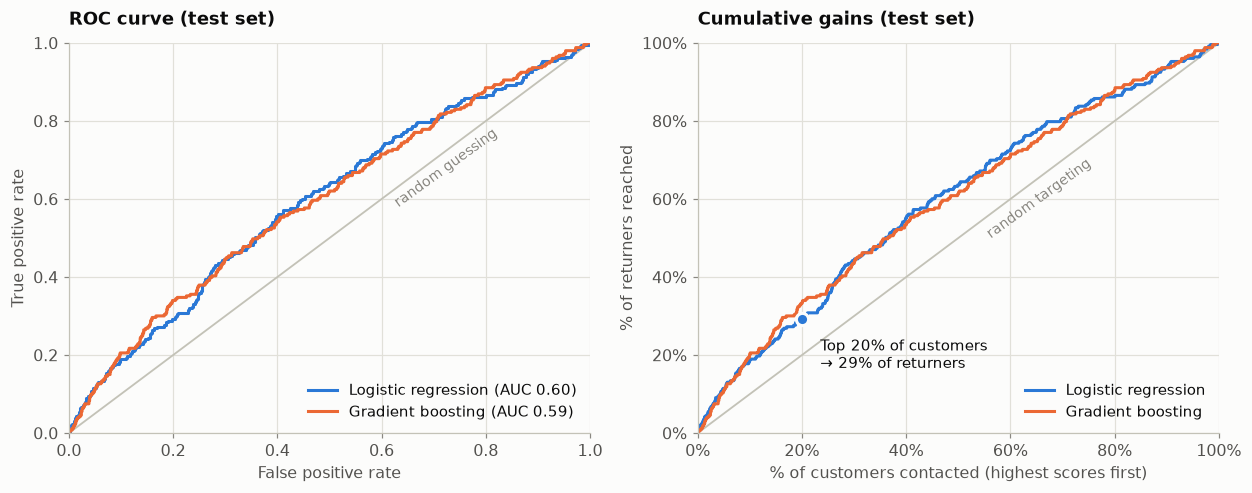

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
colors = {"Logistic regression": BLUE, "Gradient boosting": ORANGE}

ax = axes[0]
ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1.2)
ax.annotate("random guessing", (0.62, 0.58), color=MUTED, fontsize=9, rotation=36)
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y_test, s)
    ax.plot(fpr, tpr, color=colors[name], label=f"{name} (AUC {roc_auc_score(y_test, s):.2f})")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curve (test set)"); ax.legend(loc="lower right", fontsize=9.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
pct = np.linspace(0, 100, 101)
ax.plot(pct, pct, color=AXIS, linewidth=1.2)
ax.annotate("random targeting", (55, 50), color=MUTED, fontsize=9, rotation=36)
for name, s in scores.items():
    order = np.argsort(-s)
    captured = np.cumsum(y_test.values[order]) / y_test.sum() * 100
    xs = np.arange(1, len(s) + 1) / len(s) * 100
    ax.plot(xs, captured, color=colors[name], label=name)
lr_order = np.argsort(-scores["Logistic regression"])
cap20 = y_test.values[lr_order][: int(len(y_test) * 0.2)].sum() / y_test.sum() * 100
ax.plot(20, cap20, "o", color=BLUE, markersize=8, markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
ax.annotate(f"Top 20% of customers\n→ {cap20:.0f}% of returners", (20, cap20), xytext=(12, -32),
            textcoords="offset points", color=INK, fontsize=9.5)
ax.set_xlabel("% of customers contacted (highest scores first)")
ax.set_ylabel("% of returners reached")
ax.set_title("Cumulative gains (test set)"); ax.legend(loc="lower right", fontsize=9.5)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
for a in axes:
    a.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0) if a is axes[1] else mtick.StrMethodFormatter("{x:.1f}"))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.tight_layout(); plt.show()

**Reading of the results**

- **The model is better than random, but only modestly.** The test ROC-AUC is above 0.5, and the top-scored customers do return more often than average.
- **This is not a strong predictor.** Most returners still look like non-returners at the moment of their first purchase.
- That fits the wider story: repeat orders on Olist are driven mostly by **new, unrelated needs** rather than by a relationship formed on the first order.
- The model is still useful because the economics are favourable: the top 10–20% of customers by score send a much better return signal than random outreach.

**Model choice, revisited.** Gradient boosting reaches slightly more returners at the top end, but the ROC-AUC is effectively the same. We keep logistic regression because it was chosen on cross-validation, the test set is small, and the simpler model is easier to explain.

## 8. What drives the prediction?

Logistic-regression coefficients are easiest to read as **odds ratios**. An odds ratio of 1.5 means the odds of coming back are 1.5× higher.

- For **categorical** features, the ratio is relative to the reference category.
- For **numeric** features, it applies per one standard-deviation increase.

We retrain the baseline model on all labelled customers (train + test) so the interpretation uses the full sample.

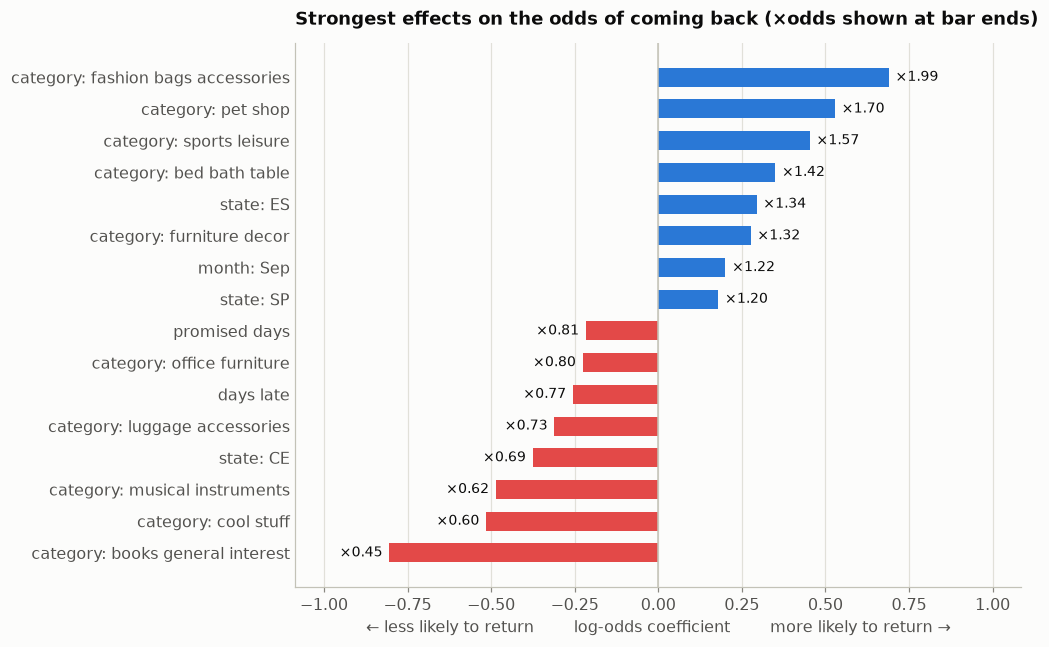

In [18]:
interp_model = make_pipeline(preprocess, LogisticRegression(C=0.1, class_weight="balanced", max_iter=2000))
X_interp = X_all.copy()
X_interp["main_category"] = collapse_rare(X_interp, X_all, "main_category", 25)
X_interp["state"] = collapse_rare(X_interp, X_all, "state", 12)
interp_model.fit(X_interp, y_all)

names = interp_model[0].get_feature_names_out()
coefs = pd.Series(interp_model[-1].coef_[0], index=names)
pretty = (coefs.rename(lambda n: n.replace("num__", "").replace("cat__", "").replace("main_category_", "category: ")
                       .replace("state_", "state: ").replace("payment_type_", "payment: ")
                       .replace("purchase_month_", "month: ").replace("purchase_weekday_", "weekday: ")
                       .replace("_", " ")))
top = pd.concat([pretty.nsmallest(8), pretty.nlargest(8)]).sort_values()

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.barh(top.index, top.values, height=0.6, color=[BLUE if v > 0 else RED for v in top.values])
for yv, v in enumerate(top.values):
    ax.text(v + (0.02 if v > 0 else -0.02), yv, f"×{np.exp(v):.2f}", va="center",
            ha="left" if v > 0 else "right", color=INK, fontsize=9)
ax.axvline(0, color=AXIS, linewidth=1)
lim = np.abs(top.values).max() * 1.35
ax.set_xlim(-lim, lim)
ax.set_xlabel("← less likely to return        log-odds coefficient        more likely to return →")
ax.set_title("Strongest effects on the odds of coming back (×odds shown at bar ends)")
ax.grid(axis="y", visible=False); ax.tick_params(axis="y", length=0)
plt.tight_layout(); plt.show()

- **What customers buy first matters most.** Fashion accessories, pet shop, sports & leisure, bed/bath and furniture/decor raise the odds. Books, gadgets ("cool stuff"), musical instruments and luggage lower them.
- **Where they live matters.** Customers in Espírito Santo (ES) and São Paulo (SP) are more likely to return; those in Ceará (CE) are less likely.
- **Delivery matters only after controlling for everything else.** Longer promised times and more days late both lower the odds, but this signal overlaps with location and product mix.
- **Review score, voucher use and several first-day orders have small effects** once the model includes the bigger signals. The multi-order effect is real but affects very few customers.

## 9. Can the model be improved?

The baseline already uses the obvious features. Since gradient boosting does not beat logistic regression, a fancier **algorithm** is not the answer. Better **features** are more promising.

We add three groups of features and keep the same guardrail: choose on cross-validation, then check the test set once.

| Group | New features | Why it may help |
|---|---|---|
| **Seller and product history** | main seller and product; how many orders that seller and product had *before* this purchase | Some sellers and products create repeat habits; established sellers may deliver a better experience |
| **Finer location** | customer city and 3-digit postcode; seller state; whether customer and seller are in the same state | State is too coarse. City and postcode capture local effects, and seller location proxies delivery distance |
| **Engagement and basket detail** | review-survey response time; whether the review has a title; comment length; most units bought of one product; hour of purchase | Quick responders look more engaged; large baskets may signal consumables or reseller behaviour |

**Target encoding without leakage.** Sellers, products, cities and postcode areas have too many values for one-hot encoding. Target encoding replaces each value with the average return rate of customers who share it, but done naively it **leaks the outcome**. scikit-learn's `TargetEncoder` avoids this with **cross-fitting**: each row is encoded using rates from the other folds only, so the model sees only past information.

**Point-in-time history.** "How many orders had this seller made before?" counts only orders placed *before* the customer's purchase, so no future information is used.

In [19]:
# Point-in-time order counts for every seller and product (orders sorted by purchase time)
order_times = df[["order_id", "order_purchase_timestamp"]]
seller_orders = (items[["order_id", "seller_id"]].drop_duplicates().merge(order_times, on="order_id")
                 .sort_values("order_purchase_timestamp"))
seller_orders["seller_prior_orders"] = seller_orders.groupby("seller_id").cumcount()
product_orders = (items[["order_id", "product_id"]].drop_duplicates().merge(order_times, on="order_id")
                  .sort_values("order_purchase_timestamp"))
product_orders["product_prior_orders"] = product_orders.groupby("product_id").cumcount()

def build_extra_features(customer_ids: pd.Index) -> pd.DataFrame:
    fo = df[(df.purchase_day == df.first_day) & df.customer_unique_id.isin(customer_ids)]
    feats = pd.DataFrame(index=customer_ids)

    it = (items.merge(fo[["order_id", "customer_unique_id"]], on="order_id")
               .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
               .merge(seller_orders[["order_id", "seller_id", "seller_prior_orders"]], on=["order_id", "seller_id"], how="left")
               .merge(product_orders[["order_id", "product_id", "product_prior_orders"]], on=["order_id", "product_id"], how="left"))
    priciest = it.sort_values("price", ascending=False).drop_duplicates("customer_unique_id").set_index("customer_unique_id")

    # Seller and product history
    feats["main_seller"] = priciest.seller_id
    feats["main_product"] = priciest.product_id
    feats["seller_prior_orders"] = np.log1p(priciest.seller_prior_orders)
    feats["product_prior_orders"] = np.log1p(priciest.product_prior_orders)

    # Finer location
    feats["city"] = cust.loc[customer_ids, "city"]
    feats["zip3"] = cust.loc[customer_ids, "zip"].str[:3]
    feats["seller_state"] = priciest.seller_state
    feats["same_state_seller"] = (feats.seller_state == cust.loc[customer_ids, "state"]).astype(float)

    # Engagement and basket detail
    feats["max_units_one_product"] = it.groupby(["customer_unique_id", "product_id"]).size().groupby(level=0).max()
    feats["purchase_hour"] = fo.groupby("customer_unique_id").order_purchase_timestamp.min().dt.hour
    r = reviews.merge(fo[["order_id", "customer_unique_id"]], on="order_id")
    r["answer_hours"] = (r.review_answer_timestamp - r.review_creation_date).dt.total_seconds() / 3600
    r["has_title"] = r.review_comment_title.notna()
    r["comment_len"] = r.review_comment_message.fillna("").str.len()
    gr = r.groupby("customer_unique_id")
    feats["review_answer_hours"] = np.log1p(gr.answer_hours.min())
    feats["review_has_title"] = gr.has_title.max().astype(float)
    feats["comment_length"] = gr.comment_len.max()
    return feats

X_ext = X_all.join(build_extra_features(labelled.index))
TE_COLS = ["main_seller", "main_product", "city", "zip3"]
EXTRA_CAT = ["seller_state"]
EXTRA_NUM = ["seller_prior_orders", "product_prior_orders", "same_state_seller", "max_units_one_product",
             "purchase_hour", "review_answer_hours", "review_has_title", "comment_length"]
print(f"{X_ext.shape[1]} features ({X_all.shape[1]} baseline + {X_ext.shape[1] - X_all.shape[1]} new)")
X_ext[TE_COLS].nunique().rename("distinct values").to_frame()

35 features (22 baseline + 13 new)


,distinct values
main_seller,1959
main_product,19538
city,3576
zip3,844


In [20]:
def prepare(X, reference):
    # Collapse rare categories using counts from `reference` only, and make encoded IDs plain strings
    X = X.copy()
    for col, n in [("main_category", 25), ("state", 12), ("seller_state", 8)]:
        X[col] = collapse_rare(X, reference, col, n)
    for col in TE_COLS:
        X[col] = X[col].fillna("missing").astype(str)
    return X

X2 = prepare(X_ext, X_ext[is_train])
X2_train, X2_test = X2[is_train], X2[~is_train]
ALL_NUM, ALL_CAT = NUM_COLS + EXTRA_NUM, CAT_COLS + EXTRA_CAT

def make_lr(num, cat, te, C):
    parts = [("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num),
             ("cat", OneHotEncoder(handle_unknown="ignore"), cat)]
    if te:
        parts.append(("te", make_pipeline(TargetEncoder(target_type="binary", random_state=RANDOM_STATE),
                                          StandardScaler()), te))
    return make_pipeline(ColumnTransformer(parts),
                         LogisticRegression(C=C, class_weight="balanced", max_iter=3000))

def make_gb(num, cat, te, **params):
    parts = [("te", TargetEncoder(target_type="binary", random_state=RANDOM_STATE), te),
             ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1), cat),
             ("num", "passthrough", num)]
    is_cat = [False] * len(te) + [True] * len(cat) + [False] * len(num)
    settings = dict(learning_rate=0.03, max_iter=400, max_depth=3, min_samples_leaf=200, random_state=RANDOM_STATE)
    settings.update(params)
    return make_pipeline(ColumnTransformer(parts), HistGradientBoostingClassifier(categorical_features=is_cat, **settings))

BASELINE = "Baseline: logistic regression"
LR_NEW = "New features: logistic regression"
LR_NEW_REG = "New features: logistic regression, C=0.01"
GB_NEW = "New features: gradient boosting, depth 2"
BLEND = "New features: blend of LR (C=0.01) + GB"
CANDIDATES = {
    BASELINE: lambda: make_lr(NUM_COLS, CAT_COLS, [], C=0.1),
    LR_NEW: lambda: make_lr(ALL_NUM, ALL_CAT, TE_COLS, C=0.1),
    LR_NEW_REG: lambda: make_lr(ALL_NUM, ALL_CAT, TE_COLS, C=0.01),
    GB_NEW: lambda: make_gb(ALL_NUM, ALL_CAT, TE_COLS, max_depth=2),
}

def fit_and_score(name, X_fit, y_fit, X_pred):
    # Returns scores for X_pred. The blend averages the two models' rank percentiles.
    if name == BLEND:
        a = fit_and_score(LR_NEW_REG, X_fit, y_fit, X_pred)
        b = fit_and_score(GB_NEW, X_fit, y_fit, X_pred)
        return (rankdata(a) + rankdata(b)) / (2 * len(a))
    model = CANDIDATES[name]()
    model.fit(X_fit, y_fit)
    return model.predict_proba(X_pred)[:, 1]

### Step 1: choose on cross-validation (training period only)

The **selection rule is fixed in advance**: the candidate with the highest mean CV ROC-AUC wins. We also check how often each model beats the baseline across the 5 folds, so the gain has to be consistent rather than coming from a single lucky fold.

In [21]:
folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X2_train, y_train))
fold_aucs = {}
for name in list(CANDIDATES) + [BLEND]:
    fold_aucs[name] = [roc_auc_score(y_train.iloc[va], fit_and_score(name, X2_train.iloc[tr], y_train.iloc[tr], X2_train.iloc[va]))
                       for tr, va in folds]
fold_aucs = pd.DataFrame(fold_aucs)

cv_table = pd.DataFrame({
    "CV ROC-AUC (mean)": fold_aucs.mean(),
    "std": fold_aucs.std(),
    "folds better than baseline": [(fold_aucs[c] > fold_aucs[BASELINE]).sum() if c != BASELINE else None for c in fold_aucs],
})
CHOSEN = cv_table["CV ROC-AUC (mean)"].idxmax()
print(f"Chosen by CV: {CHOSEN}")
cv_table.round(3)

Chosen by CV: New features: blend of LR (C=0.01) + GB


,CV ROC-AUC (mean),std,folds better than baseline
Baseline: logistic regression,0.559,0.021,NaN
New features: logistic regression,0.570,0.025,5.000
"New features: logistic regression, C=0.01",0.575,0.025,5.000
"New features: gradient boosting, depth 2",0.568,0.024,4.000
New features: blend of LR (C=0.01) + GB,0.579,0.025,5.000


### Step 2: check the chosen model once on the test set

We report every candidate on the test set for transparency, but the choice above is not revisited.

In [22]:
test_scores = {name: fit_and_score(name, X2_train, y_train, X2_test) for name in list(CANDIDATES) + [BLEND]}
test_table = pd.DataFrame({
    name: {"ROC-AUC": roc_auc_score(y_test, s), "PR-AUC": average_precision_score(y_test, s),
           "Lift @ top 10%": lift_at(y_test, s, 0.10), "Lift @ top 20%": lift_at(y_test, s, 0.20)}
    for name, s in test_scores.items()
}).T
test_table.round(3)

,ROC-AUC,PR-AUC,Lift @ top 10%,Lift @ top 20%
Baseline: logistic regression,0.597,0.029,1.858,1.463
New features: logistic regression,0.616,0.032,1.976,1.739
"New features: logistic regression, C=0.01",0.623,0.034,2.055,1.799
"New features: gradient boosting, depth 2",0.606,0.028,1.897,1.660
New features: blend of LR (C=0.01) + GB,0.624,0.030,2.095,1.739


In [23]:
# Is the gain real? Paired bootstrap: resample the test customers and recompute both AUCs on the same draws
rng = np.random.default_rng(RANDOM_STATE)
yv, s_new, s_old = y_test.values, test_scores[CHOSEN], test_scores[BASELINE]
gains = []
for _ in range(2000):
    i = rng.integers(0, len(yv), len(yv))
    gains.append(roc_auc_score(yv[i], s_new[i]) - roc_auc_score(yv[i], s_old[i]))
gains = np.array(gains)
lo, hi = np.percentile(gains, [2.5, 97.5])
print(f"Test ROC-AUC: baseline {roc_auc_score(yv, s_old):.3f} → chosen model {roc_auc_score(yv, s_new):.3f}")
print(f"Paired bootstrap gain: {gains.mean():+.3f} points (95% CI {lo:+.3f} to {hi:+.3f}); share of resamples with no gain: {(gains <= 0).mean():.1%}")
print(f"CV gain per fold vs baseline: {np.round(fold_aucs[CHOSEN] - fold_aucs[BASELINE], 3).tolist()}")

Test ROC-AUC: baseline 0.597 → chosen model 0.624
Paired bootstrap gain: +0.027 points (95% CI +0.003 to +0.052); share of resamples with no gain: 1.5%
CV gain per fold vs baseline: [0.018, 0.025, 0.014, 0.021, 0.02]


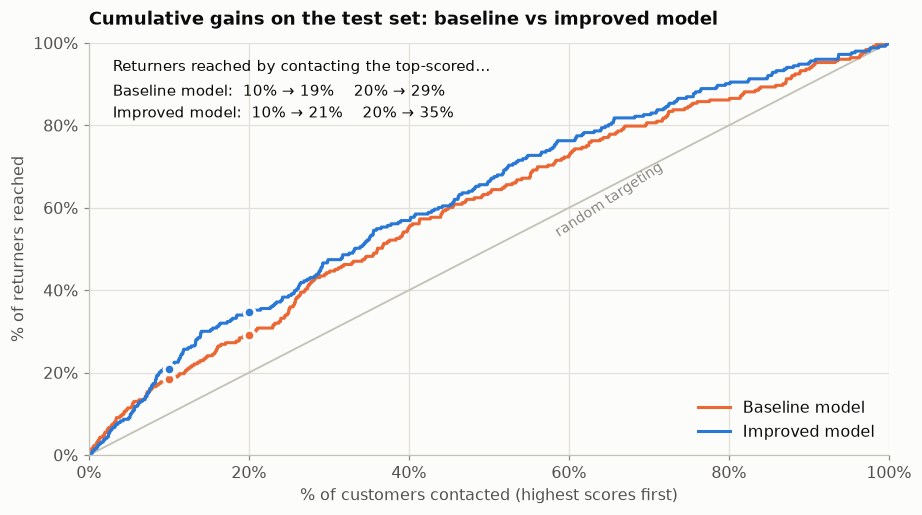

In [24]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot([0, 100], [0, 100], color=AXIS, linewidth=1.2)
ax.annotate("random targeting", (58, 53), color=MUTED, fontsize=9, rotation=33)
summary_lines = ["Returners reached by contacting the top-scored…"]
for name, color, label in [(BASELINE, ORANGE, "Baseline model"), (CHOSEN, BLUE, "Improved model")]:
    s = test_scores[name]
    order = np.argsort(-s)
    captured = np.cumsum(yv[order]) / yv.sum() * 100
    xs = np.arange(1, len(s) + 1) / len(s) * 100
    ax.plot(xs, captured, color=color, label=label)
    reached = {}
    for q in (10, 20):
        reached[q] = yv[order][: int(len(yv) * q / 100)].sum() / yv.sum() * 100
        ax.plot(q, reached[q], "o", color=color, markersize=7, markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
    summary_lines.append(f"{label}:  10% → {reached[10]:.0f}%    20% → {reached[20]:.0f}%")
ax.text(3, 97, "\n".join(summary_lines), va="top", ha="left", fontsize=9.5, color=INK, linespacing=1.6)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0)); ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlabel("% of customers contacted (highest scores first)"); ax.set_ylabel("% of returners reached")
ax.set_title("Cumulative gains on the test set: baseline vs improved model")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "model_cumulative_gains.png", dpi=150, bbox_inches="tight")
plt.show()

### What do the new features say?

The logistic-regression half of the model is still interpretable. Here are the new features' effects, as odds ratios per one standard deviation for numeric features, or versus other states for the seller's state.

In [25]:
lr_new = CANDIDATES[LR_NEW_REG]().fit(X2_train, y_train)
coef_new = pd.Series(lr_new[-1].coef_[0], index=lr_new[0].get_feature_names_out())
keep = [n for n in coef_new.index if any(k in n for k in EXTRA_NUM + TE_COLS + ["seller_state_"])]
new_effects = (coef_new[keep].rename(lambda n: n.replace("num__", "").replace("te__", "").replace("cat__", ""))
               .to_frame("coefficient"))
new_effects["odds ratio"] = np.exp(new_effects.coefficient)
new_effects.sort_values("coefficient").round(3)

,coefficient,odds ratio
seller_state_SC,-0.296,0.743
seller_state_DF,-0.209,0.812
product_prior_orders,-0.121,0.886
review_answer_hours,-0.116,0.891
comment_length,-0.084,0.919
purchase_hour,-0.081,0.922
same_state_seller,-0.060,0.942
seller_state_RS,-0.009,0.991
max_units_one_product,-0.008,0.992
zip3,0.001,1.001


The new features' individual effects are small, which is typical once dozens of weak signals are combined. A few still stand out:

- **Engagement:** faster review responses are linked to more repeat purchases; longer comments are slightly negative, which fits the idea that complaints are more likely to be written at length.
- **Seller quality:** customers from sellers with stronger repeat histories, and from more established sellers, are more likely to come back.
- **Bestsellers are one-offs:** products that many people had already bought are less likely to convert a customer into a repeat buyer.
- **Seller location:** some seller states are clearly stronger than others, but this overlaps with delivery and product mix.


## 10. Putting the model to work: scoring today's one-time customers

The model is most useful for customers who bought **recently** and have not come back yet: every one-time buyer from the last 180 days. This includes the "Recent Buyers" segment from notebook 1 and extends further back. These customers were excluded from training because their 180-day window is not yet complete, so they are exactly the group we can still act on.

Before scoring, we refit the chosen model on **all** labelled customers (train + test) so it learns from the most recent data too.


In [26]:
X2_full = prepare(X_ext, X_ext)

open_customers = cust[(cust.first_day > DATA_END - pd.Timedelta(days=WINDOW)) & cust.return_day.isna()]
X_open = build_features(open_customers.index).join(build_extra_features(open_customers.index))
X_open = prepare(X_open, X_ext)

campaign = pd.DataFrame({
    "first_purchase": open_customers.first_day.dt.date,
    "main_category": X_open.main_category,
    "state": X_open.state,
    "return_score": fit_and_score(CHOSEN, X2_full, y_all, X_open),
}, index=open_customers.index)
campaign["score_decile"] = pd.qcut(campaign.return_score.rank(method="first"), 10, labels=range(10, 0, -1)).astype(int)
campaign = campaign.sort_values("return_score", ascending=False)
campaign.index.name = "customer_unique_id"
campaign.to_csv(OUTPUT_DIR / "repeat_purchase_scores.csv")

print(f"Scored {len(campaign):,} one-time customers from the last {WINDOW} days → outputs/repeat_purchase_scores.csv")
print("Decile 1 = most likely to come back. Suggested campaign: deciles 1–2.")
campaign.head(10)

Scored 36,901 one-time customers from the last 180 days → outputs/repeat_purchase_scores.csv
Decile 1 = most likely to come back. Suggested campaign: deciles 1–2.


,first_purchase,main_category,state,return_score,score_decile
customer_unique_id,,,,,
c1dffa0ed8695e4823f90ae4550e336e,2018-08-09,bed_bath_table,SP,0.999,1
399a2a06a7ddefb3b09460ba6a1bcf12,2018-05-07,fashion_bags_accessories,SP,0.999,1
7edfa2876fa97b99672bc1b31efab6be,2018-08-01,bed_bath_table,SP,0.999,1
b61dd513f7cca03e7c2c55fb80fa1772,2018-08-15,pet_shop,SP,0.999,1
d8d7254ce52510c5a5c38db3ab5b9c4e,2018-08-26,bed_bath_table,SP,0.998,1
888126f1b154332995c01125378db342,2018-08-16,sports_leisure,SP,0.998,1
69e6cc87a9eb80c6815799251e83150c,2018-07-31,sports_leisure,SP,0.998,1
91c3c2b10f62dc342c721e0b7f73cc58,2018-04-20,bed_bath_table,SP,0.997,1
3d1909f3fcbd1a322ac9b0ab2e2e8f24,2018-05-03,sports_leisure,SP,0.997,1


In [28]:
top2 = campaign[campaign.score_decile <= 2]
print(f"Customers in deciles 1–2: {len(top2):,}")
print("Most common first-purchase categories in deciles 1–2:")
(top2.main_category.str.replace("_", " ").value_counts(normalize=True).head(5) * 100).round(1).rename("% of targeted").to_frame()

Customers in deciles 1–2: 7,380
Most common first-purchase categories in deciles 1–2:


,% of targeted
main_category,
bed bath table,24.100
sports leisure,17.200
furniture decor,11.500
other,9.900
health beauty,8.000


**Caveat:** the scores are **relative rankings** (0–1 rank percentiles when the blend is used), not probabilities. Use the deciles to decide who to contact.

## Conclusions

**Cohort retention**
- Retention stays below 1% in every cohort, and the 90-day return rate remains under 2% even as the business grows.
- Growth came almost entirely from new customers; repeat buying is still rare.

**Repeat-purchase prediction**
- The baseline model is modest but real: test ROC-AUC is around 0.60.
- Better features matter more than a more complex algorithm. The added seller, product, location and engagement signals improve the model consistently in cross-validation and on the test set.
- The strongest signals are the product category, seller quality and local delivery context, not just the model choice itself.

**Recommendation:** focus retention spend on the top 20% of recent one-time buyers by score in `repeat_purchase_scores.csv`. Use a holdout group to confirm the campaign is creating extra repeat purchases, not just picking up customers who would have bought anyway.

## Limitations and next steps

- The model has a clear ceiling: most returners still look like everyone else at the first purchase.
- The improvement is real but modest, and one test period is not enough to be definitive.
- These are association scores, not causal effects.
- For ROI work, use calibrated probabilities rather than rank scores.
- The next useful step is uplift modelling or seller-level analysis, rather than more tuning of the same features.
